In [21]:

# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [33]:
scalar = np.array(5)
T = np.array([[5,6,6],[3,6,7]])
for name , arr in (('matrix',matrix),):
   print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')
print('ADD T to itself \n',T+T);
print('Transpose T \n',T.T)
print(' shape of T after tranpsoe\n',T.shape)
print('reshape to (3,2)',T.reshape(3,2))


matrix  ndim=2  shape=(2, 3)
ADD T to itself 
 [[10 12 12]
 [ 6 12 14]]
Transpose T 
 [[5 3]
 [6 6]
 [6 7]]
 shape of T after tranpsoe
 (2, 3)
reshape to (3,2) [[5 6]
 [6 3]
 [6 7]]


In [30]:
import numpy as np
import numpy.linalg as la

def cosine_similarity(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

pairs = [
    (np.array([4,5,6]), np.array([6,7,8])),
    (np.array([4,5,6]), np.array([4,5,6])),
    (np.array([6,7,8]), np.array([6,7,5]))
]

max_similarity = -1
most_similar_pair = None

for i, (u, v) in enumerate(pairs, start=1):

    similarity = cosine_similarity(u, v)

    print(f"Pair {i}: {similarity:.4f}")

    if similarity > max_similarity:
        max_similarity = similarity
        most_similar_pair = i

print("\nMost Similar Pair:", most_similar_pair)
print("Maximum Cosine Similarity:", round(max_similarity, 4))

Pair 1: 0.9990
Pair 2: 1.0000
Pair 3: 0.9764

Most Similar Pair: 2
Maximum Cosine Similarity: 1.0


In [32]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
print('inverse of m:\n', la.inv(M))
print('trace of m:', np.trace(M))

# 2. M @ inv(M) == I ?
inv_M = la.inv(M)
identity_check = np.allclose(M @ inv_M, np.eye(M.shape[0]))
print('M @ inv(M) == I ?', identity_check)

# 3. Is M symmetric? Is P orthogonal?
is_m_symmetric = np.allclose(M, M.T)
print('Is M symmetric?', is_m_symmetric)

is_p_orthogonal = np.allclose(P @ P.T, np.eye(P.shape[0])) and np.allclose(P.T @ P, np.eye(P.shape[0]))
print('Is P orthogonal?', is_p_orthogonal)

inverse of m:
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
trace of m: 7.0
M @ inv(M) == I ? True
Is M symmetric? True
Is P orthogonal? True


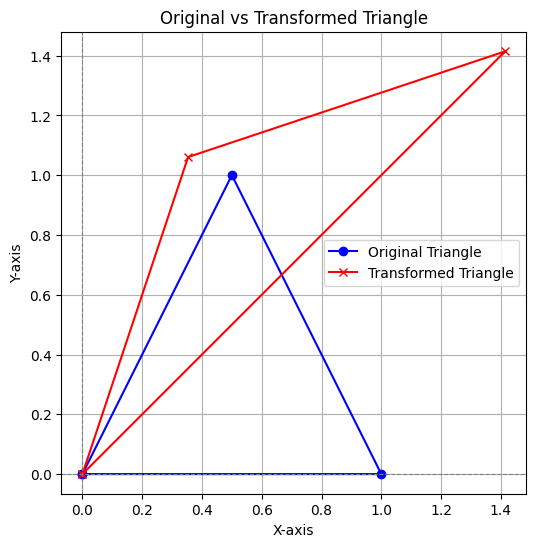

In [36]:
import matplotlib.pyplot as plt

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
scaling_matrix = np.array([[2, 0],
                           [0, 0.5]])

# 2. Rotation matrix (45 degrees)
theta = np.deg2rad(45) # Convert 45 degrees to radians
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                            [np.sin(theta),  np.cos(theta)]])

# 3. Apply both and plot original vs transformed
# Apply scaling first, then rotation
transformed_tri = rotation_matrix @ (scaling_matrix @ tri)

plt.figure(figsize=(6,6))
plt.plot(tri[0, [0,1,2,0]], tri[1, [0,1,2,0]], 'b-o', label='Original Triangle')
plt.plot(transformed_tri[0, [0,1,2,0]], transformed_tri[1, [0,1,2,0]], 'r-x', label='Transformed Triangle')
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True)
plt.axis('equal')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Original vs Transformed Triangle')
plt.legend()
plt.show()

In [38]:
C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
# Using np.linalg.eig to get eigenvalues (w) and eigenvectors (v)
# w contains eigenvalues, v contains eigenvectors (column-wise)
w, v = la.eig(C)

# 2. print eigenvalues
print('Eigenvalues:', w)

# 3. verify A v = lambda v for the first eigenvector
# Select the first eigenvalue and its corresponding eigenvector
lambda1 = w[0]
v1 = v[:, 0] # First eigenvector is the first column

# Calculate C @ v1
Cv1 = C @ v1

# Calculate lambda1 * v1
lambda_v1 = lambda1 * v1

print('\nVerification for first eigenvector:')
print('C @ v1:', Cv1)
print('lambda1 * v1:', lambda_v1)
# Check if they are approximately equal
print('C @ v1 == lambda1 * v1 ?', np.allclose(Cv1, lambda_v1))

Eigenvalues: [5. 2.]

Verification for first eigenvector:
C @ v1: [3.536 3.536]
lambda1 * v1: [3.536 3.536]
C @ v1 == lambda1 * v1 ? True


In [40]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x2 = la.solve(A2, b2)
print('Solution for A2 x = b2:', x2)

# 2. Rank of A2
rank_A2 = la.matrix_rank(A2)
print('Rank of A2:', rank_A2)

# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
# Assuming cosine_similarity function is defined in a previous cell
sim_cat_dog = cosine_similarity(cat, dog)
sim_cat_car = cosine_similarity(cat, car)

print('\nCosine similarity (cat, dog):', sim_cat_dog)
print('Cosine similarity (cat, car):', sim_cat_car)

if sim_cat_dog > sim_cat_car:
    print('Cat and dog are more similar.')
else:
    print('Cat and car are more similar.')

Solution for A2 x = b2: [1. 2.]
Rank of A2: 2

Cosine similarity (cat, dog): 0.9946195449838785
Cosine similarity (cat, car): 0.29255678516966266
Cat and dog are more similar.
